<a href="https://colab.research.google.com/github/SaumyaMalhotra/Natural-Language-Processing-NLP-Notebook/blob/main/word_embadding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import spacy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Fake_Real_Data.csv to Fake_Real_Data (1).csv


In [3]:
df=pd.read_csv('Fake_Real_Data.csv')
df

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real
...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake
9896,Trump consults Republican senators on Fed chie...,Real
9897,Trump lawyers say judge lacks jurisdiction for...,Real
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake


In [4]:
df['label'].value_counts()


,count
label,
Fake,5000
Real,4900


In [5]:
df['label_num'] = df['label'].map({'Fake' : 0, 'Real': 1})

#check the results with top 5 rows
df.head(5)

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


In [9]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [10]:
nlp = spacy.load("en_core_web_lg")

print("Model loaded successfully!")

Model loaded successfully!


In [13]:
df['vectors']=df['Text'].apply(lambda text: nlp(text).vector)

In [14]:
df.head(5)

,Text,label,label_num,vectors
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.103623025, 0.17802684, -0.11873861, -0.034..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.0063406364, 0.16712041, -0.06661373, 0.017..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.122753024, 0.17192385, -0.024732638, -0.06..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.027337318, 0.12501417, -0.0073965387, -0.0..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.032708026, 0.093958504, -0.03287002, -0.00..."


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['vectors'].values,
    df['label_num'],
    test_size=0.2,
    random_state=2022)

In [38]:
X_test.shape

(1980,)

In [39]:
X_train.shape

(7920,)

In [40]:
X_train_2D=np.stack(X_train)
X_test_2D=np.stack(X_test)

In [41]:
X_test_2D.shape

(1980, 300)

In [42]:
X_train_2D.shape

(7920, 300)

In [43]:
from sklearn.naive_bayes import MultinomialNB
from  sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [45]:
nb_pipeline = Pipeline([
    ('scale', MinMaxScaler()),
    ('model', MultinomialNB())
])

# Train
nb_pipeline.fit(X_train_2D, y_train)

# Predict
y_pred = nb_pipeline.predict(X_test_2D)

# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1024
           1       0.95      0.95      0.95       956

    accuracy                           0.95      1980
   macro avg       0.95      0.95      0.95      1980
weighted avg       0.95      0.95      0.95      1980



In [46]:
knn_pipeline = Pipeline([
    ('scale', MinMaxScaler()),
    ('model', KNeighborsClassifier(
        n_neighbors=5,
        metric='euclidean'
    ))
])

knn_pipeline.fit(X_train_2D, y_train)

y_pred = knn_pipeline.predict(X_test_2D)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1024
           1       0.96      0.99      0.97       956

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



Text(70.72222222222221, 0.5, 'Truth')

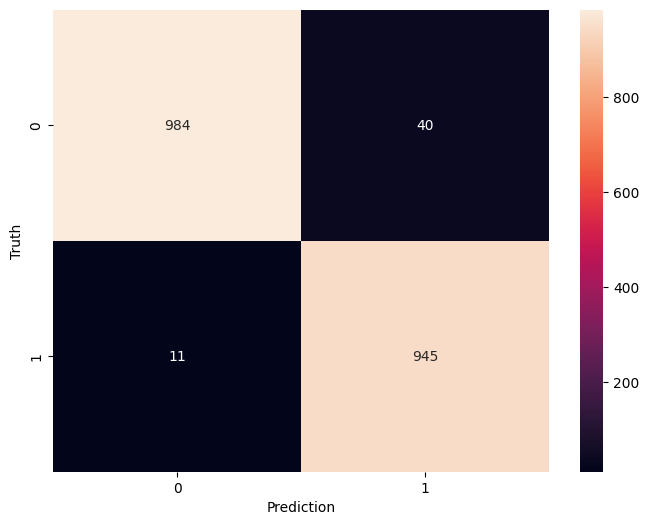

In [48]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (8,6))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

# **EXERCISE**

In [49]:
from google.colab import files
uploaded = files.upload()

Saving news_dataset_new.json to news_dataset_new.json


In [50]:
df1=pd.read_json("news_dataset_new.json")
df1.head(5)

,text,category
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS
3,This Richard Sherman Interception Literally Sh...,SPORTS
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS


In [52]:
df1["category"].value_counts()

,count
category,
CRIME,2500
SPORTS,2500
BUSINESS,2500


In [53]:
nlp=spacy.load("en_core_web_lg")

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [55]:
df1['Category_num'] = le.fit_transform(df1['category'])
df1.head(5)

,text,category,Category_num
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,1
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,1
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,2
3,This Richard Sherman Interception Literally Sh...,SPORTS,2
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,0


In [56]:
df1['Category_num'].value_counts()

,count
Category_num,
1,2500
2,2500
0,2500


In [73]:
df1['text'].loc[3]

'Richard Sherman Interception Literally Shook World Richard Sherman good football .'

In [74]:
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return ' '.join(filtered_tokens)

preprocess("This Richard Sherman Interception Literally Shook The World Richard Sherman is good at football.")

'Richard Sherman Interception literally shake World Richard Sherman good football'

In [75]:
df1['text']=df1['text'].apply(preprocess)
df1.head(5)

,text,category,Category_num,vectors
0,Larry Nassar blame Victims say victimize newly...,CRIME,1,"[-0.22982927, 0.25056115, -0.14943781, -0.0582..."
1,woman Beats Cancer die fall horse,CRIME,1,"[-0.17343672, 0.4643714, -0.01551457, 0.036826..."
2,Vegas Taxpayers spend Record $ 750 million New...,SPORTS,2,"[0.04127065, 0.09119062, -0.04817366, -0.21621..."
3,Richard Sherman Interception literally shake W...,SPORTS,2,"[-0.046651963, 0.23345126, 0.032655705, -0.103..."
4,7 thing totally kill weed Legalization Buzz,BUSINESS,0,"[-0.17344216, 0.120945714, -0.044293143, -0.17..."


In [76]:
df1['vectors']=df1['text'].apply(lambda text: nlp(text).vector)

In [77]:
df1.sample(5)

,text,category,Category_num,vectors
5318,Samsung halt Production Sales Galaxy Note 7 ph...,BUSINESS,0,"[-0.17175047, 0.29240403, 0.0073140655, 0.0263..."
3975,16 Senators U.S. Women Hockey Team Fair Pay bo...,SPORTS,2,"[-0.15838589, 0.13208616, 0.0080174785, 0.0240..."
7347,Algeria Pile Goals Milestone World Cup Win,SPORTS,2,"[-0.082661666, 0.14299247, 0.029986003, 0.1763..."
5295,LeBron James totally deny Possibility star Spa...,SPORTS,2,"[-0.033597376, 0.075474665, -0.025413724, -0.0..."
1405,Louisiana Deputy Gets 40 year Prison kill Boy ...,CRIME,1,"[-0.24238671, 0.17877813, 0.00011697598, -0.13..."


In [78]:
X_train , X_test , y_train , y_test = train_test_split(
    df1['vectors'].values,
    df1['Category_num'],
    test_size=0.2,
    random_state=2022
)

In [79]:
X_train_2D=np.stack(X_train)
X_test_2D=np.stack(X_test)

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('scale', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        C=1.0
    ))
])

model.fit(X_train_2D, y_train)

y_pred = model.predict(X_test_2D)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       535
           1       0.89      0.90      0.89       486
           2       0.91      0.91      0.91       479

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500

